# Leakage field with a continuous grounded Al plane (no opening)

This companion notebook evaluates the geometry with **no aperture** in the 500 nm Al layer. The Al is held at 0 V, the Si beneath it is biased, and the observation point is 75 µm above the Al. Electric fields are reported in **V/mm**.

The main result follows directly from electrostatic uniqueness: an ideal, continuous grounded conductor completely shields the air half-space. A separate finite-width calculation is included only as a conservative edge-sensitivity proxy for the 1 cm chip.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "mathtext.fontset": "dejavusans",
})

COLORS = {"blue": "#275D8C", "orange": "#D17A22", "red": "#B33A3A", "gray": "#5B6573", "green": "#2A8C6A"}

In [2]:
# SI units internally
V_si = 10.0                  # Si bias, V
V_al = 0.0                   # continuous grounded Al, V
z_obs = 75e-6                # observation height above Al, m
t_al = 500e-9                # Al thickness, m
d_si = 675e-6                # Si thickness, m
chip_width = 1.0e-2          # 1 cm square chip / Al plane, m
half_chip = chip_width / 2
bias_sweep = np.linspace(1.0, 100.0, 400)
selected_biases = np.array([1.0, 5.0, 10.0, 25.0, 50.0, 100.0])

print("NO-OPENING GEOMETRY")
print(f"  Si bias                  : {V_si:.1f} V")
print(f"  continuous Al plane      : {V_al:.1f} V")
print(f"  Al thickness             : {t_al*1e9:.0f} nm")
print(f"  observation height       : {z_obs*1e6:.0f} µm")
print(f"  chip width               : {chip_width*1e2:.1f} cm")

NO-OPENING GEOMETRY
  Si bias                  : 10.0 V
  continuous Al plane      : 0.0 V
  Al thickness             : 500 nm
  observation height       : 75 µm
  chip width               : 1.0 cm


## 1. Exact ideal result: zero field above the metal

In the air region above a continuous grounded conductor,

$$\nabla^2 V = 0, \qquad V(x,y,0)=0, \qquad V\rightarrow 0\ \text{far from the device}. $$

By the uniqueness theorem, the only solution is

$$V(x,y,z)=0, \qquad \mathbf{E}(x,y,z)=-\nabla V=\mathbf{0}. $$

Therefore the ideal leakage field at 75 µm is exactly **0 V/mm for every Si bias**. The 675 µm Si thickness and 500 nm Al thickness do not change this air-side solution. This assumes the Si and Al are electrically isolated; an ohmic Si–Al contact cannot simultaneously be assigned 10 V and 0 V.

EXACT AIR-SIDE RESULT FOR CONTINUOUS GROUNDED AL
  potential at z = 75 µm : 0.000000 V
  |E| at z = 75 µm       : 0.000000 V/mm

 bias       ideal leakage field
    1.0 V         0.000000 V/mm
    5.0 V         0.000000 V/mm
   10.0 V         0.000000 V/mm
   25.0 V         0.000000 V/mm
   50.0 V         0.000000 V/mm
  100.0 V         0.000000 V/mm


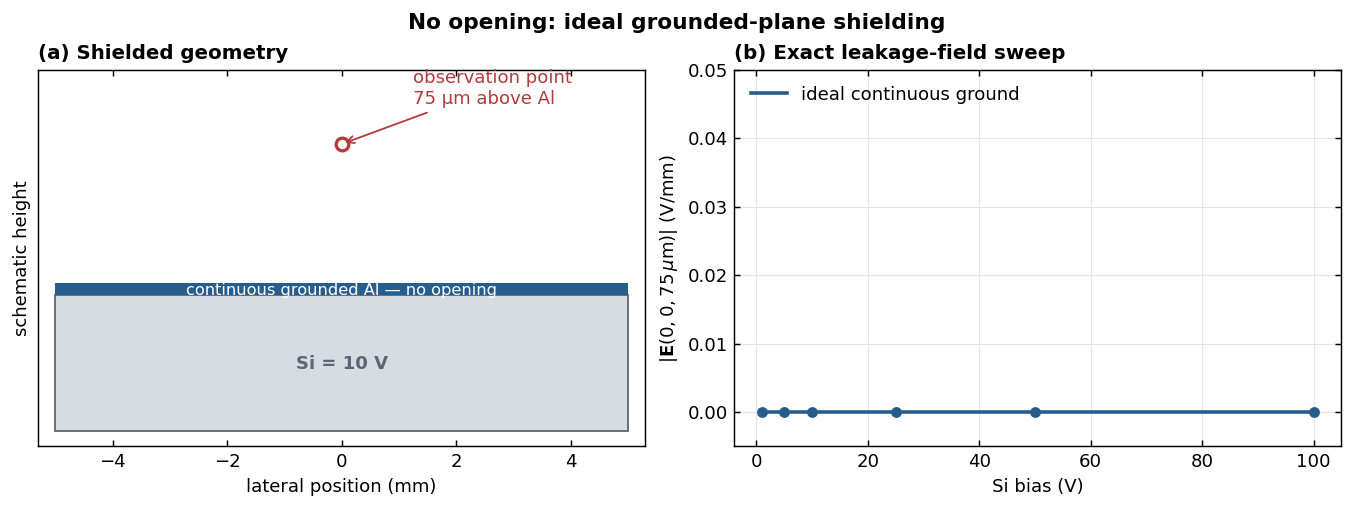

In [3]:
ideal_potential = np.zeros_like(bias_sweep)
ideal_field = np.zeros_like(bias_sweep)  # V/mm

print("EXACT AIR-SIDE RESULT FOR CONTINUOUS GROUNDED AL")
print(f"  potential at z = 75 µm : {0.0:.6f} V")
print(f"  |E| at z = 75 µm       : {0.0:.6f} V/mm")
print("\n bias       ideal leakage field")
for vb in selected_biases:
    print(f" {vb:6.1f} V       {0.0:10.6f} V/mm")

fig, axes = plt.subplots(1, 2, figsize=(10.3, 3.8), constrained_layout=True)

# Cross-sectional schematic (not to scale vertically)
axes[0].add_patch(Rectangle((-5, -0.675), 10, 0.675, facecolor="#D7DCE2", edgecolor=COLORS["gray"], label="Si at bias"))
axes[0].add_patch(Rectangle((-5, 0), 10, 0.06, facecolor=COLORS["blue"], edgecolor="none", label="continuous Al, 0 V"))
axes[0].plot(0, 0.75, "o", ms=7, mfc="white", mec=COLORS["red"], mew=1.8)
axes[0].annotate("observation point\n75 µm above Al", xy=(0, 0.75), xytext=(1.25, 0.95),
                 arrowprops=dict(arrowstyle="->", color=COLORS["red"]), color=COLORS["red"])
axes[0].text(0, 0.025, "continuous grounded Al — no opening", ha="center", va="center", color="white", fontsize=9)
axes[0].text(0, -0.34, f"Si = {V_si:g} V", ha="center", va="center", color=COLORS["gray"], fontweight="bold")
axes[0].set(xlim=(-5.3, 5.3), ylim=(-0.75, 1.12), xlabel="lateral position (mm)", ylabel="schematic height")
axes[0].set_yticks([])
axes[0].set_title("(a) Shielded geometry", loc="left", fontweight="bold")

axes[1].plot(bias_sweep, ideal_field, color=COLORS["blue"], label="ideal continuous ground")
axes[1].scatter(selected_biases, np.zeros_like(selected_biases), s=25, color=COLORS["blue"], zorder=3)
axes[1].set(xlabel="Si bias (V)", ylabel=r"$|\mathbf{E}(0,0,75\,\mu\mathrm{m})|$ (V/mm)", ylim=(-0.005, 0.05))
axes[1].set_title("(b) Exact leakage-field sweep", loc="left", fontweight="bold")
axes[1].grid(True, color="#E1E5E9", lw=0.6)
axes[1].legend(loc="upper left")

fig.suptitle("No opening: ideal grounded-plane shielding", fontweight="bold")
plt.show()

## 2. Finite-width edge sensitivity

The exact zero-field result applies to an unbroken grounded boundary enclosing the biased material from the air side. A real 1 cm chip has edges, so a nonzero center field can arise if biased surfaces are exposed around those edges. Its value is not uniquely determined by the information above; it depends on the sidewalls, backside, package, and nearby conductors.

For scale only, consider a deliberately conservative 3D boundary model: a grounded 1 cm × 1 cm square in the plane $z=0$, with the entire plane outside that square held at the Si bias. This maximizes edge excitation and is **not** the ideal continuous-ground result. By superposition, its center field is the complement of the exact rectangular-patch solution.

CONSERVATIVE FINITE-EDGE PROXY — NOT THE IDEAL SHIELDED RESULT
  1 cm square, 10 V, z=75 µm potential : 0.135035 V
  1 cm square, 10 V, z=75 µm field     : 1.800126 V/mm

 bias       ideal ground       conservative edge proxy
    1.0 V        0.00000 V/mm            0.18001 V/mm
    5.0 V        0.00000 V/mm            0.90006 V/mm
   10.0 V        0.00000 V/mm            1.80013 V/mm
   25.0 V        0.00000 V/mm            4.50032 V/mm
   50.0 V        0.00000 V/mm            9.00063 V/mm
  100.0 V        0.00000 V/mm           18.00126 V/mm


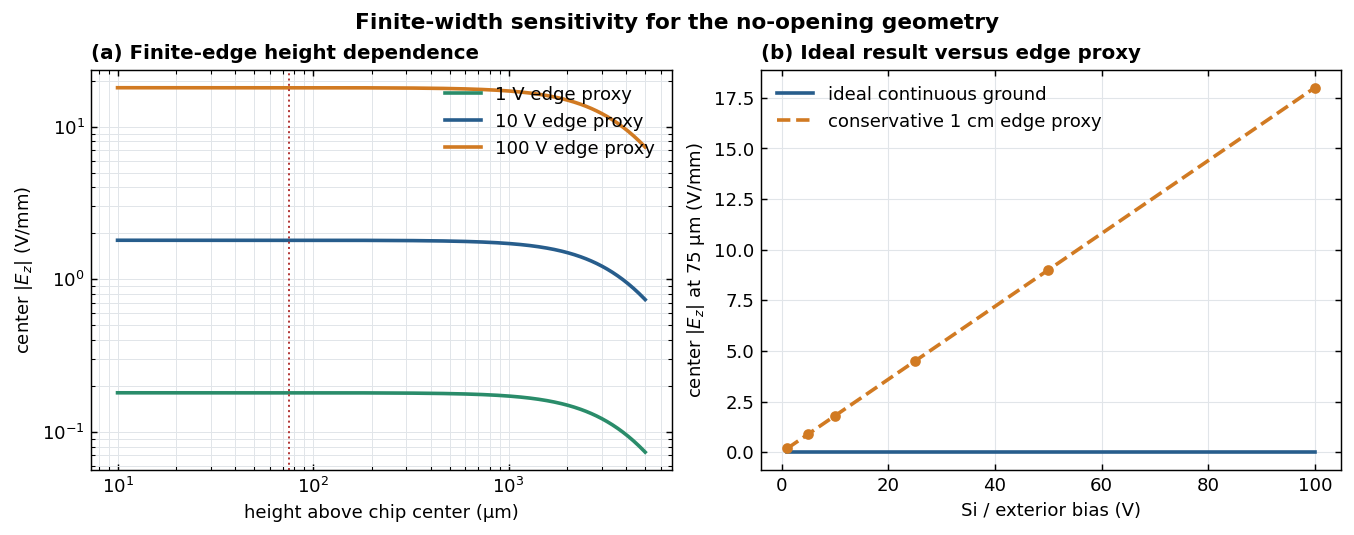

In [4]:
def rectangle_center_solid_angle(z, half_x, half_y):
    z = np.asarray(z, float)
    return 4.0 * np.arctan(half_x * half_y / (z * np.sqrt(z**2 + half_x**2 + half_y**2)))


def rectangle_center_field(z, half_x, half_y, voltage):
    """Magnitude of the normal field from a rectangular voltage patch."""
    z = np.asarray(z, float)
    c = half_x**2 + half_y**2
    q = half_x * half_y / (z * np.sqrt(z**2 + c))
    return (2 * voltage / np.pi) * (q / (1 + q**2)) * (2*z**2 + c) / (z * (z**2 + c))


def edge_proxy_potential(z, voltage):
    omega = rectangle_center_solid_angle(z, half_chip, half_chip)
    return voltage * (1.0 - omega / (2*np.pi))


edge_field_10 = float(rectangle_center_field(z_obs, half_chip, half_chip, V_si) / 1e3)
edge_potential_10 = float(edge_proxy_potential(z_obs, V_si))
edge_sweep = rectangle_center_field(z_obs, half_chip, half_chip, bias_sweep) / 1e3
edge_selected = rectangle_center_field(z_obs, half_chip, half_chip, selected_biases) / 1e3

print("CONSERVATIVE FINITE-EDGE PROXY — NOT THE IDEAL SHIELDED RESULT")
print(f"  1 cm square, 10 V, z=75 µm potential : {edge_potential_10:.6f} V")
print(f"  1 cm square, 10 V, z=75 µm field     : {edge_field_10:.6f} V/mm")
print("\n bias       ideal ground       conservative edge proxy")
for vb, ee in zip(selected_biases, edge_selected):
    print(f" {vb:6.1f} V      {0.0:9.5f} V/mm          {ee:9.5f} V/mm")

z_line = np.geomspace(10e-6, 5e-3, 500)
fig, axes = plt.subplots(1, 2, figsize=(10.3, 4.0), constrained_layout=True)

for vb, color in zip([1.0, 10.0, 100.0], [COLORS["green"], COLORS["blue"], COLORS["orange"]]):
    e_line = rectangle_center_field(z_line, half_chip, half_chip, vb) / 1e3
    axes[0].loglog(z_line*1e6, e_line, color=color, label=f"{vb:g} V edge proxy")
axes[0].axvline(z_obs*1e6, color=COLORS["red"], lw=1.1, ls=":")
axes[0].set(xlabel="height above chip center (µm)", ylabel=r"center $|E_z|$ (V/mm)")
axes[0].set_title("(a) Finite-edge height dependence", loc="left", fontweight="bold")
axes[0].grid(True, which="both", color="#E1E5E9", lw=0.55)
axes[0].legend()

axes[1].plot(bias_sweep, ideal_field, color=COLORS["blue"], label="ideal continuous ground")
axes[1].plot(bias_sweep, edge_sweep, color=COLORS["orange"], ls="--", label="conservative 1 cm edge proxy")
axes[1].scatter(selected_biases, edge_selected, s=24, color=COLORS["orange"], zorder=3)
axes[1].set(xlabel="Si / exterior bias (V)", ylabel=r"center $|E_z|$ at 75 µm (V/mm)")
axes[1].set_title("(b) Ideal result versus edge proxy", loc="left", fontweight="bold")
axes[1].grid(True, color="#E1E5E9", lw=0.6)
axes[1].legend()

fig.suptitle("Finite-width sensitivity for the no-opening geometry", fontweight="bold")
plt.show()

## 3. Conclusion

- **Device result under the ideal continuous-ground assumption:** $E=0$ V/mm at 75 µm for every bias from 1–100 V.
- The buried Si voltage cannot leak through a perfect continuous grounded Al sheet; only openings, seams, finite edges, or imperfect grounding create an external field.
- The finite-edge curve is a deliberately conservative reference boundary condition, not a prediction. A device-specific edge result requires the exposed sidewall/backside geometry and surrounding conductors.